
<div style="padding:24px 26px;border-radius:14px;background:linear-gradient(135deg,#16324F,#2F6F7E);margin-bottom:20px;box-shadow:0 6px 18px rgba(22,50,79,0.14);">
<h1 style="margin:0;color:white;font-size:34px;">Cardiac Patient Monitoring System</h1>
<p style="margin:8px 0 0 0;color:#EAF3F5;font-size:18px;">Milestone 1 — Understanding the Data</p>
<p style="margin:6px 0 0 0;color:#DDECEF;font-size:14px;">Heart Disease Cleveland Dataset · Data Understanding & Quality Check</p>
</div>



<div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:12px;padding:18px 20px;margin:12px 0 18px 0;">
<h2 style="color:#16324F;margin-top:0;">Introduction</h2>
<p style="color:#3F4A52;">This project starts with the <b>Heart Disease Cleveland dataset</b>, which contains clinical information for patients that may be related to heart disease.</p>
<p style="color:#3F4A52;">Before moving into modeling, I first want to understand the patients represented in the dataset and check whether the available information is reliable enough for later analysis.</p>
<p style="color:#3F4A52;">The dataset contains <b>303 patient records</b>, described by <b>13 input features</b>, while the <code>target</code> column represents the outcome that will later be predicted.</p>
<div style="background:#F6F9FA;border-left:4px solid #2F6F7E;border-radius:8px;padding:13px 15px;margin-top:14px;">
<p style="color:#16324F;font-weight:bold;margin-top:0;">Main Question</p>
<p style="color:#3F4A52;margin-bottom:0;">Is the data itself ready to be trusted before machine learning begins?</p>
</div>
</div>



<div style="background:#F6F9FA;border:1px solid #DCE5E8;border-radius:12px;padding:16px 18px;margin:12px 0 20px 0;">
<p style="color:#16324F;font-weight:bold;font-size:18px;margin-top:0;">Milestone 1 Roadmap</p>
<div style="display:flex;flex-wrap:wrap;align-items:center;gap:8px;color:#3F4A52;">
<span style="background:white;padding:8px 12px;border-radius:8px;">Load Data</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:white;padding:8px 12px;border-radius:8px;">Inspect Structure</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:white;padding:8px 12px;border-radius:8px;">Check Quality</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:white;padding:8px 12px;border-radius:8px;">Validate Values</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:#DDECEF;padding:8px 12px;border-radius:8px;color:#16324F;font-weight:bold;">Save Checked Data</span>
</div>
</div>


<h2 style="color:#16324F;font-weight:bold;">Environment</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">This project is developed in Jupyter Notebook using Python with Pandas, NumPy, Matplotlib, and Scikit-learn.</p></div>

In [109]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.12.13
Pandas version: 3.0.3
NumPy version: 2.5.1


<h2 style="color:#16324F;font-weight:bold;">Dataset Source</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#3F4A52;margin:0;">The dataset used in this project is the <b>Heart Disease Cleveland dataset</b>, downloaded from Kaggle for educational machine-learning analysis.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">1. Loading the Dataset</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Before changing or cleaning anything, I want to see the data exactly as it was provided.</p></div>

In [110]:
# Load the Cleveland Heart Disease dataset
df = pd.read_csv("../data/Heart_disease_cleveland_new.csv")

# Display the first five patient records
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The first rows show that the dataset contains both numerical measurements and features represented using numeric codes. The <code>target</code> column is also included and will later be used as the outcome for the classification task.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">2. How Large Is the Dataset?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Knowing the number of patient records and columns gives a clearer picture of the amount of data available for the analysis.</p></div>

In [111]:
# Check the number of rows and columns
df.shape

(303, 14)

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The dataset contains <b>303 patient records and 14 columns</b>. Among these columns, <b>13 are input features</b> and <code>target</code> is the outcome for classification.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">3. What Information Does Each Patient Record Contain?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Next, I will inspect the available columns to understand what type of information is stored for each patient.</p></div>

In [112]:
# Display all column names
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The dataset contains 13 patient features and one target column. Some columns contain direct numerical measurements, while others use numbers to represent categories.</p></div>


<h2 style="color:#2F6F7E;font-weight:bold;">4. Data Dictionary</h2>

| Feature | Description |
|---|---|
| `age` | Age of the patient in years |
| `sex` | Sex of the patient: 0 = female, 1 = male |
| `cp` | Chest pain type: 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic |
| `trestbps` | Resting blood pressure in mm Hg |
| `chol` | Serum cholesterol in mg/dl |
| `fbs` | Fasting blood sugar > 120 mg/dl: 0 = false, 1 = true |
| `restecg` | Resting ECG result: 0 = normal, 1 = ST-T abnormality, 2 = left ventricular hypertrophy |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina: 0 = no, 1 = yes |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment: 0 = upsloping, 1 = flat, 2 = downsloping |
| `ca` | Number of major vessels |
| `thal` | Thal result: 1 = normal, 2 = fixed defect, 3 = reversible defect |
| `target` | Heart disease status: 0 = absence, 1 = presence |


<h2 style="color:#2F6F7E;font-weight:bold;">5. Checking the Dataset Structure</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Before cleaning the data, I want to inspect the data types and make sure each column contains the expected number of values.</p></div>

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">All 14 columns contain 303 non-null values. Most columns are stored as integers, while <code>oldpeak</code> is stored as a float because it contains decimal values.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">6. Are There Any Missing Values?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Missing values can affect both analysis and model training, so I need to confirm whether any patient record is incomplete.</p></div>

In [114]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">All columns have <b>0 missing values</b>, so the dataset is complete according to this check.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">7. Are There Any Duplicate Records?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Even if the dataset is complete, repeated patient records could still affect the analysis, so I will check for duplicate rows.</p></div>

In [115]:
df.duplicated().sum()

np.int64(0)

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">No duplicate rows were found, so no records need to be removed for duplication.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">8. Are the Values Reasonable?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">I will inspect the unique values of the coded categorical features to make sure they match the expected categories.</p></div>

In [116]:
categorical_col = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal", "target"
]

for column in categorical_col:
    print(f"{column}: {sorted(df[column].unique())}")

sex: [np.int64(0), np.int64(1)]
cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs: [np.int64(0), np.int64(1)]
restecg: [np.int64(0), np.int64(1), np.int64(2)]
exang: [np.int64(0), np.int64(1)]
slope: [np.int64(0), np.int64(1), np.int64(2)]
ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
thal: [np.int64(1), np.int64(2), np.int64(3)]
target: [np.int64(0), np.int64(1)]


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The coded features contain the expected category values. Binary features such as <code>sex</code>, <code>fbs</code>, <code>exang</code>, and <code>target</code> contain only 0 and 1.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">9. Checking Numerical Ranges</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Next, I will inspect the numerical measurements and check whether their ranges look reasonable.</p></div>

In [117]:
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;">Patient ages range from <b>29 to 77 years</b>, resting blood pressure from <b>94 to 200 mm Hg</b>, cholesterol from <b>126 to 564 mg/dl</b>, and maximum heart rate from <b>71 to 202 bpm</b>.</p><p style="color:#3F4A52;margin-bottom:0;">Some high values stand out, but I will keep them for now and examine them during EDA instead of removing them without evidence.</p></div>


<h2 style="color:#2F6F7E;font-weight:bold;">10. Initial Cleaning Decision</h2>
<div style="background:#F6F9FA;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 16px 0;">
<p style="color:#16324F;font-weight:bold;margin-top:0;">Cleaning Summary</p>
<ul style="color:#3F4A52;margin-bottom:0;">
<li>No missing values were found.</li>
<li>No duplicate rows were found.</li>
<li>The categorical codes matched the expected values.</li>
<li>The numerical values looked reasonable overall.</li>
<li>Some high values were kept for later EDA instead of being removed without evidence.</li>
</ul>
</div>


In [118]:
df.to_csv("../data/heart_cleveland_checked.csv", index=False)


<h2 style="color:#16324F;font-weight:bold;">Milestone 1 Takeaway</h2>
<div style="background:linear-gradient(135deg,#F8FBFC,#EAF3F5);border:1px solid #D5E5E9;border-radius:12px;padding:16px 18px;margin:10px 0 18px 0;">
<ul style="color:#3F4A52;margin-bottom:0;">
<li>The dataset contains <b>303 patient records</b>, <b>13 input features</b>, and one target column.</li>
<li>No missing values or duplicate records were found.</li>
<li>The coded categorical values matched the expected categories.</li>
<li>The numerical ranges looked reasonable overall, so no records were removed at this stage.</li>
<li>The checked dataset was saved and is ready for the next milestone: exploratory data analysis.</li>
</ul>
</div>


<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 2 — Exploratory Data Analysis & Statistics
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Understanding patient patterns before model training
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
With the dataset checked and ready, I can now explore patient patterns, relationships, and possible outliers before moving to model training.
</p>

</div>

<h2 style="
    color:#2F6F7E;
    font-weight:bold;
">
1. Target Distribution and Class Balance
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="
    color:#3F4A52;
    margin:0;
">
Before studying the patient features, I will first check how the target classes are distributed.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Question
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
">
Is the dataset balanced between patients with and without heart disease?
</p>

</div>

In [119]:
# Count patients in each target class
target_counts = df["target"].value_counts()

# Calculate the proportion of each class
target_proportions = df["target"].value_counts(normalize=True)
print("Target Counts:")
print(target_counts)
print("\nTarget Proportions:")
print(target_proportions)

Target Counts:
target
0    164
1    139
Name: count, dtype: int64

Target Proportions:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


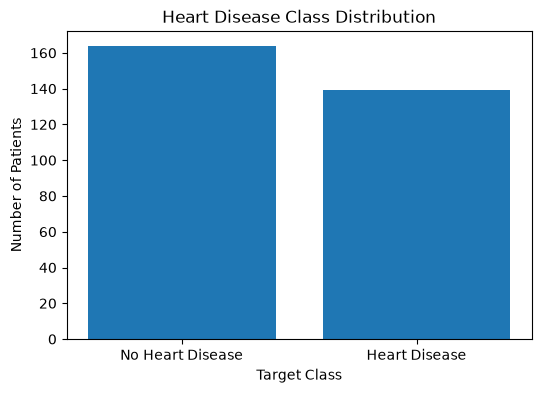

In [120]:
# Plot the target distribution
plt.figure(figsize=(6, 4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Class Distribution")

plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The dataset contains 164 patients without heart disease and 139 patients with heart disease. The difference between the two classes is only 25 patients, so the target distribution is fairly balanced.
</p>

<h2 style="color:#2F6F7E;">2. Descriptive Statistics</h2>

<p style="color:#3F4A52;">
Now I will summarize the main numerical measurements to understand the typical patient values and how much they vary.
</p>

In [121]:
# Select the main continuous numerical features
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Show descriptive statistics
df[numerical_features].describe().round(2)

,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The average patient age is about <b>54 years</b>, with most patients falling between <b>48 and 61 years</b>.<br><br>
Resting blood pressure has a mean of about <b>132 mm Hg</b>, while cholesterol has a mean of about <b>247 mg/dl</b> and shows a wider spread, reaching a maximum of <b>564 mg/dl</b>.<br><br>
The average maximum heart rate is about <b>150 bpm</b>, and <code>oldpeak</code> has a median of <b>0.80</b> but reaches as high as <b>6.20</b>, which suggests that some values may need closer inspection later.
</p>

In [122]:
# Calculate mean, median, and standard deviation
statistics_summary = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Std": df[numerical_features].std()
}).round(2)

statistics_summary

,Mean,Median,Std
age,54.44,56.0,9.04
trestbps,131.69,130.0,17.60
chol,246.69,241.0,51.78
thalach,149.61,153.0,22.88
oldpeak,1.04,0.8,1.16


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The mean and median are fairly close for <code>age</code>, <code>trestbps</code>, and <code>thalach</code>, which suggests that these features are not strongly skewed.<br><br>
For <code>chol</code> and <code>oldpeak</code>, the mean is higher than the median. This may indicate some higher values pulling the average upward.<br><br>
<code>chol</code> also has the largest standard deviation at about <b>51.78</b>, showing that cholesterol values vary more than the other features in this summary.
</p>

<h2 style="color:#2F6F7E;">3. Numerical Feature Distributions</h2>

<p style="color:#3F4A52;">
Now I will visualize the main numerical features to see how their values are distributed across the patients.
</p>

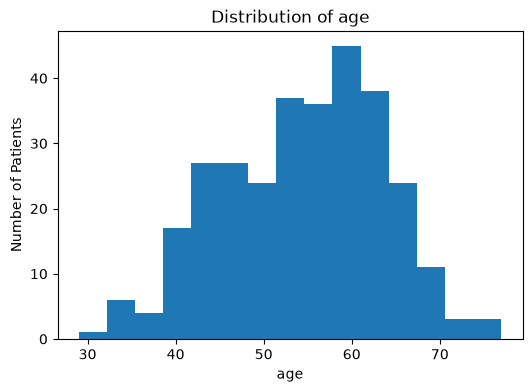

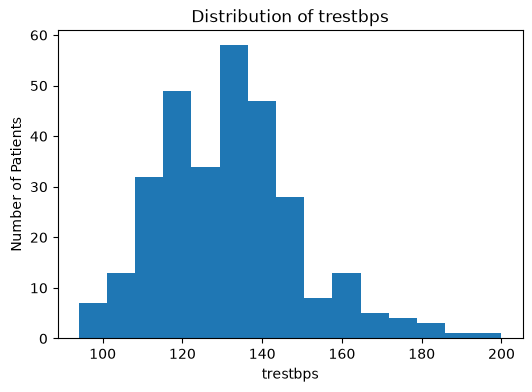

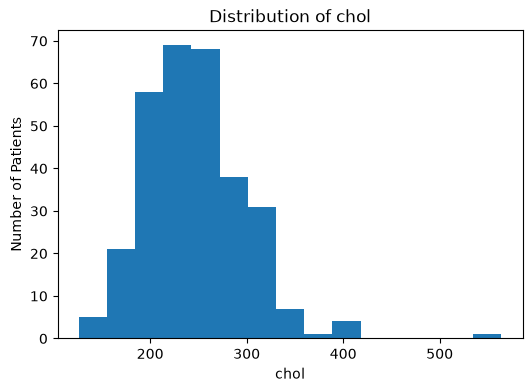

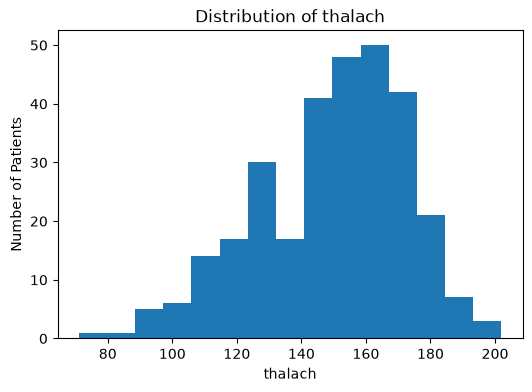

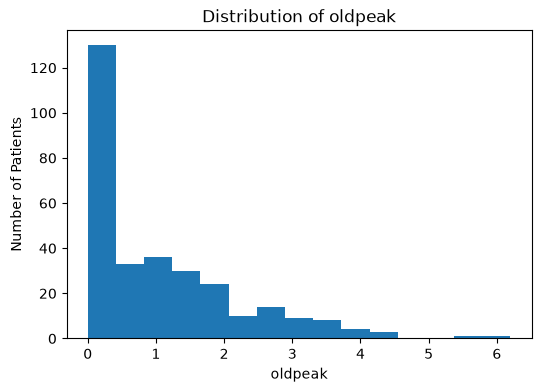

In [123]:
# Plot distributions one by one
for feature in numerical_features:
    plt.figure(figsize=(6, 4))

    plt.hist(
        df[feature],
        bins=15
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.title(f"Distribution of {feature}")

    plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The <code>age</code> distribution is concentrated mostly between the late 40s and early 60s.<br><br>

<code>trestbps</code> is centered around the 120–140 mm Hg range, with a smaller number of patients having much higher values.<br><br>

<code>chol</code> is more right-skewed than the other features, with most values around 200–300 mg/dl and a few very high values above 400 mg/dl.<br><br>

<code>thalach</code> is concentrated mainly between about 140 and 170 bpm, with fewer patients at the very low or very high ends.
</p>

<h2 style="color:#2F6F7E;font-weight:bold;">
4. Which Features Look Different Between the Two Patient Groups?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Now that I understand the overall distributions, I want to compare the main numerical features between patients with and without heart disease.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Do patients with heart disease show noticeably different values in age, cholesterol, resting blood pressure, maximum heart rate, or oldpeak?
</p>

</div>

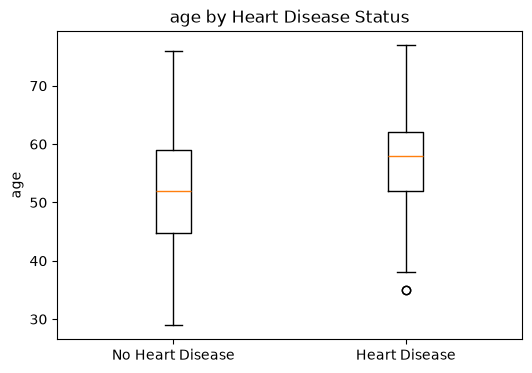

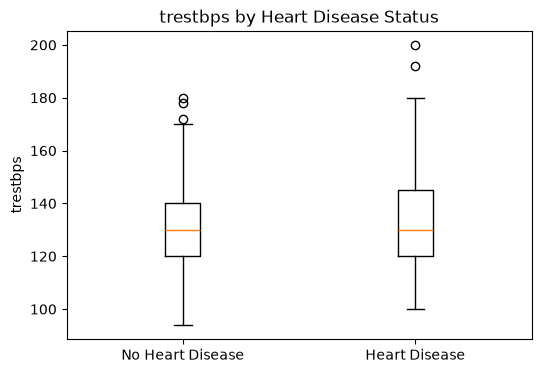

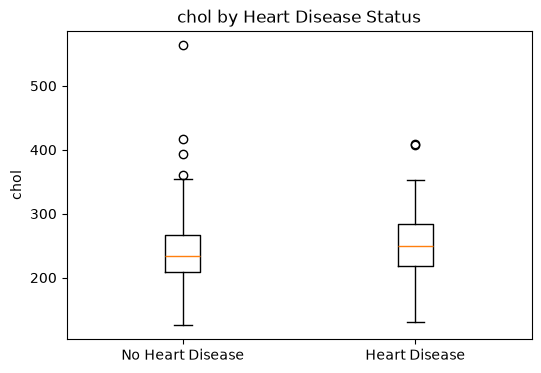

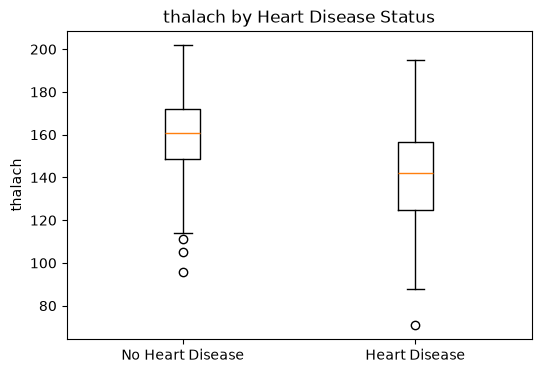

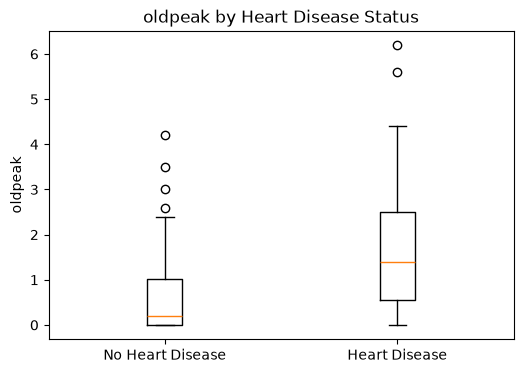

In [124]:


# Compare numerical features between the two target groups
for feature in numerical_features:
    plt.figure(figsize=(6, 4))

    group_0 = df[df["target"] == 0][feature]
    group_1 = df[df["target"] == 1][feature]

    plt.boxplot(
        [group_0, group_1],
        tick_labels=["No Heart Disease", "Heart Disease"]
    )

    plt.ylabel(feature)
    plt.title(f"{feature} by Heart Disease Status")

    plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#3F4A52;">
The boxplots show several noticeable differences between the two patient groups.
</p>

<ul style="color:#3F4A52; line-height:1.7; margin-bottom:0;">

<li>
Patients with heart disease tend to be <b>older</b>, with a higher median age than patients without heart disease.
</li>

<li>
Resting blood pressure (<code>trestbps</code>) is fairly similar between the two groups, although several high values appear as outliers.
</li>

<li>
Cholesterol (<code>chol</code>) shows only a small difference between the groups and contains some unusually high values.
</li>

<li>
Maximum heart rate (<code>thalach</code>) is noticeably <b>lower</b> for patients with heart disease.
</li>

<li>
<code>oldpeak</code> is clearly <b>higher</b> in the heart disease group, making it one of the strongest visible differences in this comparison.
</li>

</ul>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Next Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The boxplots show which features differ between the two groups, but do these features also move together or show a measurable relationship with the target?
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
5. Which Features Are Most Related to Heart Disease?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The previous comparison showed visible differences between the two patient groups. Now I will use correlation to measure the direction and strength of the relationships between the numerical features and the target.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Which features have the strongest positive or negative relationship with heart disease status?
</p>

</div>

In [125]:
# Calculate correlations between all numerical columns
correlation_matrix = df.corr(numeric_only=True)

# Show correlations with the target
target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values()
)

target_correlations

thalach    -0.417167
fbs         0.025264
chol        0.085164
trestbps    0.150825
restecg     0.169202
age         0.223120
sex         0.276816
slope       0.339213
cp          0.414446
oldpeak     0.424510
exang       0.431894
ca          0.460033
thal        0.515894
Name: target, dtype: float64

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<ul style="color:#3F4A52;line-height:1.7;margin-bottom:0;">

<li>
The strongest positive correlation with <code>target</code> is <code>thal</code> at about <b>0.516</b>, followed by <code>ca</code> at about <b>0.460</b>.
</li>

<li>
<code>exang</code>, <code>oldpeak</code>, and <code>cp</code> also show moderate positive relationships with heart disease status.
</li>

<li>
<code>thalach</code> has the strongest negative correlation at about <b>-0.417</b>, meaning higher maximum heart rate tends to be associated with the opposite target class in this dataset.
</li>

<li>
<code>fbs</code> and <code>chol</code> show very weak correlations with the target compared with the other features.
</li>

</ul>

</div>

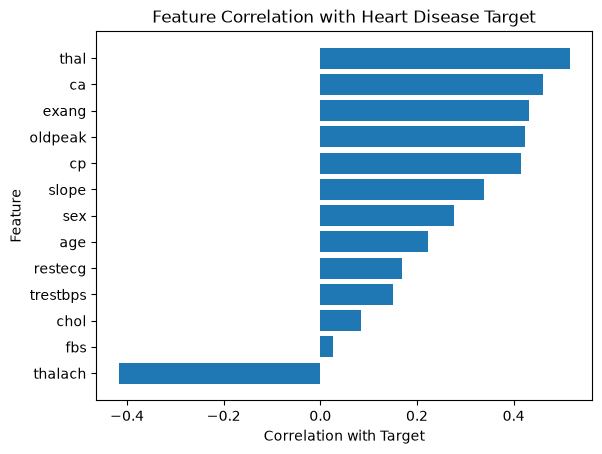

In [126]:
# Visualize correlations with the target


plt.barh(
    target_correlations.index,
    target_correlations.values
)

plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.title("Feature Correlation with Heart Disease Target")

plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
What Does This Add?
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The correlation plot supports what appeared in the earlier boxplots. Features such as <code>oldpeak</code> and <code>thalach</code> already showed visible differences between patient groups, and the correlation values now confirm that these differences are also measurable.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
6. Do Any Numerical Features Contain Unusual Values?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Earlier plots showed a few unusually high values, especially in cholesterol, resting blood pressure, and oldpeak. Before moving to modeling, I want to inspect these values more carefully instead of removing them automatically.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Which numerical features contain potential outliers, and how many unusual values appear in each one?
</p>

</div>

In [127]:
# Count potential outliers using the IQR method
outlier_summary = {}

for feature in numerical_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary[feature] = len(outliers)

outlier_summary

{'age': 0, 'trestbps': 9, 'chol': 5, 'thalach': 1, 'oldpeak': 5}

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Most numerical features contain only a small number of potential outliers.
Resting blood pressure has the highest number with <b>9 outliers</b>, while cholesterol and oldpeak each have <b>5</b>.
Age has no detected outliers, and maximum heart rate has only <b>1</b>.
Since these values may represent real patient measurements, I will keep them in the dataset instead of removing them automatically.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
7. What Do the Categorical Features Tell Us?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Several features in this dataset are stored as numbers but actually represent categories. I will now compare some of the most important categorical features with the heart disease target.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Do features such as chest pain type, exercise-induced angina, number of major vessels, and thal result show different patterns between the two patient groups?
</p>

</div>

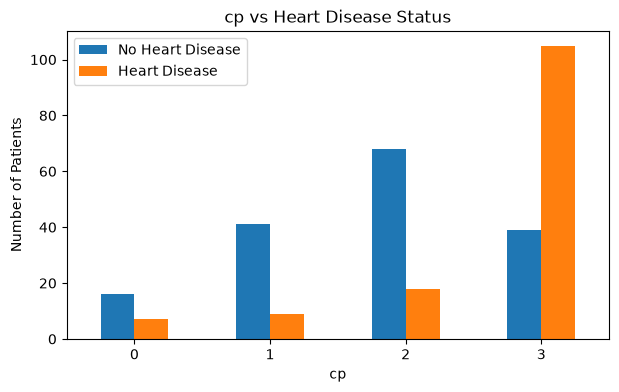

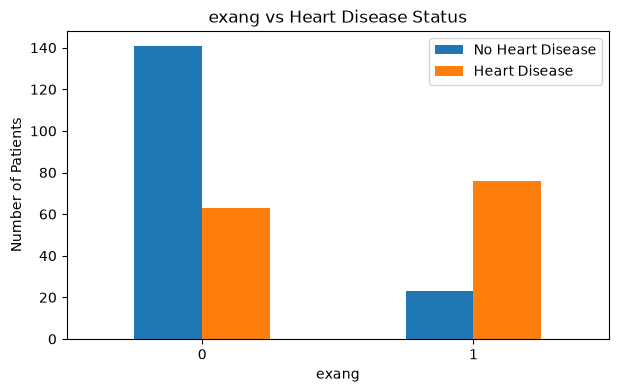

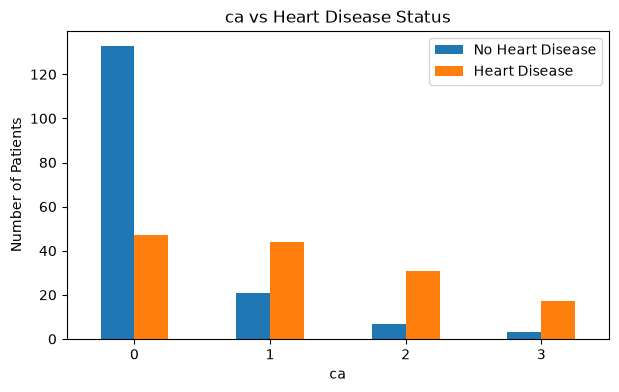

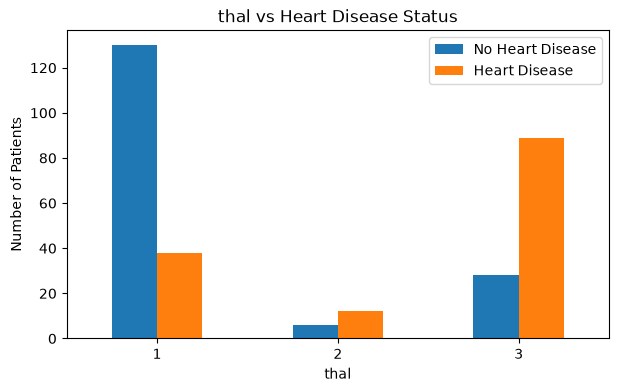

In [128]:
# Compare important categorical features with the target
categorical_features = ["cp", "exang", "ca", "thal"]

for feature in categorical_features:
    comparison = pd.crosstab(
        df[feature],
        df["target"]
    )

    comparison.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.title(f"{feature} vs Heart Disease Status")
    plt.legend(["No Heart Disease", "Heart Disease"])
    plt.xticks(rotation=0)

    plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<ul style="color:#3F4A52;line-height:1.7;margin-bottom:0;">

<li>
For <code>cp</code>, category 3 appears much more often among patients with heart disease, while the other categories are more common in patients without heart disease.
</li>

<li>
Patients with exercise-induced angina (<code>exang = 1</code>) appear more frequently in the heart disease group.
</li>

<li>
For <code>ca</code>, patients with <code>ca = 0</code> are mostly in the no-heart-disease group, while higher values appear more often in the heart disease group.
</li>

<li>
The <code>thal</code> feature shows a clear difference between the groups. <code>thal = 1</code> is more common among patients without heart disease, while <code>thal = 3</code> appears much more often among patients with heart disease.
</li>

</ul>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
8. How Do Age and Maximum Heart Rate Interact?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
So far, I looked at each feature separately. Now I want to see whether age and maximum heart rate show a different pattern across the two target groups.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Do patients with heart disease follow a different age and maximum-heart-rate pattern?
</p>

</div>

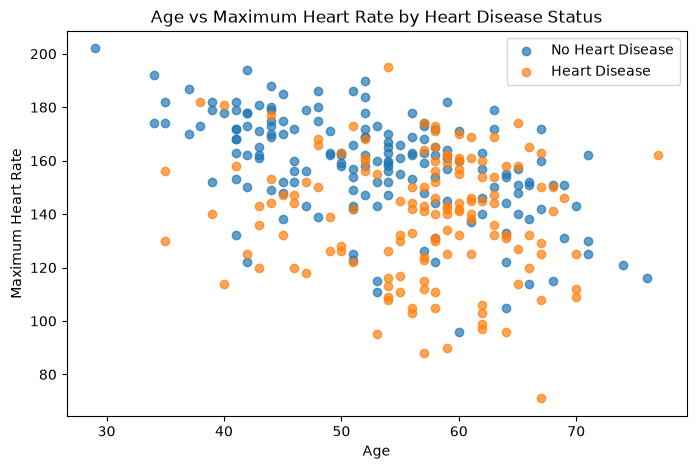

In [129]:
# Compare age and maximum heart rate by target group
plt.figure(figsize=(8, 5))

for target_value, label in [(0, "No Heart Disease"), (1, "Heart Disease")]:
    group = df[df["target"] == target_value]

    plt.scatter(
        group["age"],
        group["thalach"],
        label=label,
        alpha=0.7
    )

plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.title("Age vs Maximum Heart Rate by Heart Disease Status")
plt.legend()

plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The scatter plot shows that patients with heart disease are more concentrated in the older age range and often have lower maximum heart rates. However, the two groups still overlap, which means that age and maximum heart rate alone are not enough to clearly separate heart disease cases.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
9. Probability in Context
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The target distribution can also be viewed as a simple probability: if one patient is selected randomly from this dataset, what is the probability that the patient belongs to the heart disease group?
</p>

</div>

In [130]:
# Estimate the probability of heart disease from the dataset
heart_disease_probability = (df["target"] == 1).mean()

print(
    "Probability of heart disease:",
    round(heart_disease_probability, 3)
)

print(
    "Percentage:",
    round(heart_disease_probability * 100, 1),
    "%"
)

Probability of heart disease: 0.459
Percentage: 45.9 %


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
About <b>45.9%</b> of the patients in this dataset belong to the heart disease group. This is close to half of the dataset, which supports the earlier observation that the target classes are fairly balanced.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Milestone 2 Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
The exploratory analysis revealed several useful patterns related to heart disease while also showing considerable overlap between the two patient groups. The dataset is now better understood and ready for the next stage, where a supervised classification model will be trained and evaluated.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 3 — Supervised Learning & Baseline Model
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
From understanding patient patterns to building the first prediction model
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
The exploratory analysis revealed several patterns related to heart disease, but also showed that no single feature can clearly separate the two patient groups. The next step is to see whether these features can work together in a classification model.
</p>

</div>

<h2 style="color:#2F6F7E;">
1. Defining the Prediction Problem
</h2>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Target
</p>

<p style="color:#3F4A52;margin-bottom:0;">
<code>target = 0</code> means no heart disease, while <code>target = 1</code> means heart disease.
</p>

</div>

In [131]:
# Separate the input features from the target
X = df.drop("target", axis=1)
y = df["target"]

print("Input features shape:", X.shape)
print("Target shape:", y.shape)

Input features shape: (303, 13)
Target shape: (303,)


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The dataset now contains <b>13 input features</b> in <code>X</code> and one binary target in <code>y</code>. These variables are ready to be split into training and testing sets.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
2. Train/Test Split
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
To evaluate the model fairly, I will keep part of the data unseen during training and use it only for final testing.
</p>

</div>

In [132]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (242, 13)
Testing set: (61, 13)

Training target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Testing target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The dataset was split into <b>80% training data</b> and <b>20% testing data</b>. Stratification keeps the heart disease class proportions similar in both sets, giving a fairer evaluation later.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
3. Building the Baseline Model
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
I will start with Logistic Regression as a simple baseline classifier. This gives me a first performance reference that later models can be compared against.
</p>

</div>

In [133]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the training and testing features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the baseline Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_predictions[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

<h2 style="color:#2F6F7E;font-weight:bold;">
4. How Well Does the Baseline Model Perform?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The baseline model has been trained. Now I will evaluate its predictions using several classification metrics instead of relying on accuracy alone.
</p>

</div>

In [134]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate baseline evaluation metrics
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline Precision:", round(baseline_precision, 3))
print("Baseline Recall:", round(baseline_recall, 3))
print("Baseline F1-score:", round(baseline_f1, 3))

Baseline Accuracy: 0.869
Baseline Precision: 0.812
Baseline Recall: 0.929
Baseline F1-score: 0.867


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The baseline Logistic Regression model achieved an accuracy of about <b>0.869</b> and an F1-score of about <b>0.867</b>. Its recall is especially high at <b>0.929</b>, meaning that the model correctly identified most of the patients in the heart disease class. Precision is slightly lower at <b>0.812</b>, which means that some patients were predicted as having heart disease even though they belonged to the other class.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
5. Where Does the Baseline Model Make Mistakes?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The overall metrics are useful, but the confusion matrix shows exactly how many predictions were correct and where the model made mistakes.
</p>

</div>

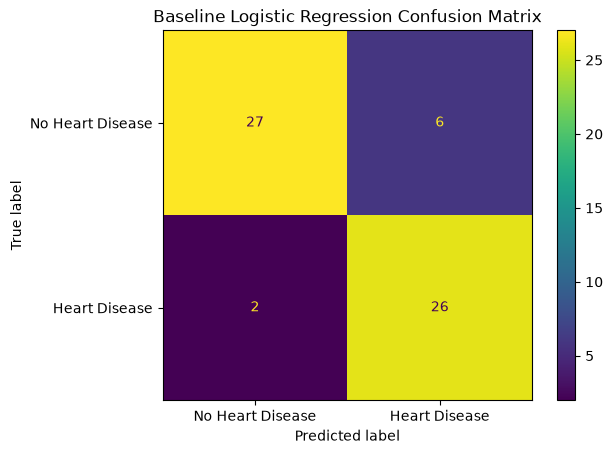

In [135]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=["No Heart Disease", "Heart Disease"]
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The confusion matrix shows that the model correctly classified <b>27 patients without heart disease</b> and <b>26 patients with heart disease</b>.

It made <b>6 false positive predictions</b>, where patients without heart disease were predicted as having it, and only <b>2 false negative predictions</b>, where patients with heart disease were missed.

The small number of false negatives explains the model's high recall of <b>0.929</b>.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:15px 17px;
    margin:10px 0 22px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Milestone 3 Takeaway
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Logistic Regression provided a strong first baseline, reaching an F1-score of <b>0.867</b> and correctly identifying most heart disease cases. The next step is to test a different classifier and see whether it can improve on this baseline.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 4 — Model Comparison & Cross-Validation
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Can another classifier perform better than the Logistic Regression baseline?
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
1. Trying a Different Classifier
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Logistic Regression gives a useful baseline, but heart disease patterns may not be completely linear. I will now try a Random Forest classifier and compare it using the same training and testing data.
</p>

</div>

In [136]:
from sklearn.ensemble import RandomForestClassifier

# Create the comparison model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train using the same training set
random_forest.fit(X_train, y_train)

# Predict the same held-out test set
rf_predictions = random_forest.predict(X_test)

rf_predictions[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

<h2 style="color:#2F6F7E;font-weight:bold;">
2. Random Forest Performance
</h2>

In [137]:
# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("Random Forest Precision:", round(rf_precision, 3))
print("Random Forest Recall:", round(rf_recall, 3))
print("Random Forest F1-score:", round(rf_f1, 3))

Random Forest Accuracy: 0.885
Random Forest Precision: 0.839
Random Forest Recall: 0.929
Random Forest F1-score: 0.881


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The Random Forest model achieved an accuracy of <b>0.885</b> and an F1-score of <b>0.881</b>. Its recall remained high at <b>0.929</b>, while precision improved to <b>0.839</b>. Compared with the Logistic Regression baseline, Random Forest performed slightly better overall.
</p>

</div>

In [138]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [baseline_accuracy, rf_accuracy],
    "Precision": [baseline_precision, rf_precision],
    "Recall": [baseline_recall, rf_recall],
    "F1-score": [baseline_f1, rf_f1]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.869,0.812,0.929,0.867
1,Random Forest,0.885,0.839,0.929,0.881


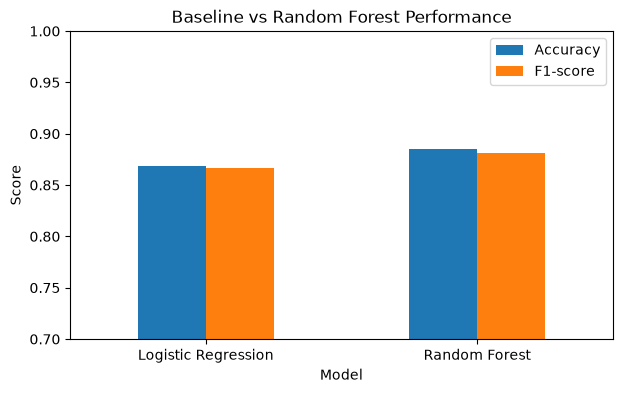

In [139]:
comparison_plot = model_comparison.set_index("Model")[["Accuracy", "F1-score"]]

comparison_plot.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Score")
plt.title("Baseline vs Random Forest Performance")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.legend()
plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Comparison
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Random Forest slightly outperformed Logistic Regression in both accuracy and F1-score, while both models achieved the same recall. This makes Random Forest the stronger model on this test split, but cross-validation is still needed to check whether this improvement is consistent.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
3. Is the Model Performance Consistent?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The test split showed that Random Forest performed slightly better, but one split may not tell the whole story. Cross-validation will help check whether the models perform consistently across different parts of the data.
</p>

</div>

In [140]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression cross-validation
logistic_cv_scores = []

for train_index, val_index in cv.split(X_train, y_train):
    X_fold_train = X_train.iloc[train_index]
    X_fold_val = X_train.iloc[val_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)

    fold_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    fold_model.fit(X_fold_train_scaled, y_fold_train)

    fold_predictions = fold_model.predict(X_fold_val_scaled)

    logistic_cv_scores.append(
        f1_score(y_fold_val, fold_predictions)
    )

logistic_cv_scores = np.array(logistic_cv_scores)

# Random Forest cross-validation
rf_cv_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression CV F1-scores:")
print(logistic_cv_scores)
print("Mean:", round(logistic_cv_scores.mean(), 3))

print("\nRandom Forest CV F1-scores:")
print(rf_cv_scores)
print("Mean:", round(rf_cv_scores.mean(), 3))

Logistic Regression CV F1-scores:
[0.86956522 0.76923077 0.7804878  0.8        0.80952381]
Mean: 0.806

Random Forest CV F1-scores:
[0.79166667 0.76923077 0.78947368 0.80851064 0.71428571]
Mean: 0.775


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Across the five folds, Logistic Regression achieved a higher mean F1-score of <b>0.806</b>, compared with <b>0.775</b> for Random Forest.

Although Random Forest performed slightly better on the held-out test set, Logistic Regression showed stronger average performance across the cross-validation folds. This shows why evaluating a model on more than one split gives a more complete picture of its performance.
</p>

</div>

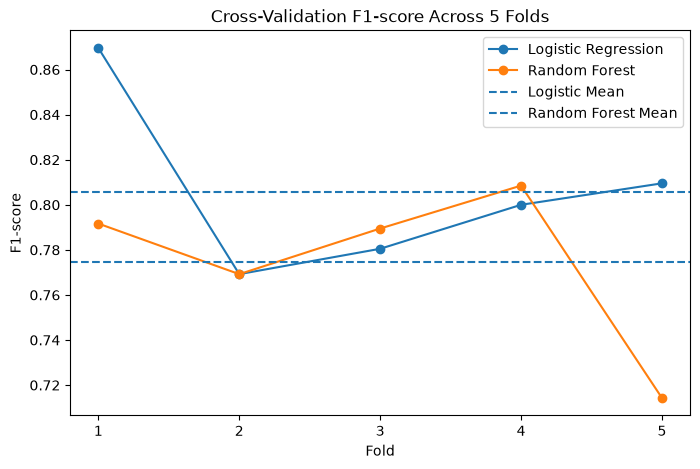

In [141]:
# Compare F1-score across the five cross-validation folds
folds = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))

plt.plot(
    folds,
    logistic_cv_scores,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    folds,
    rf_cv_scores,
    marker="o",
    label="Random Forest"
)

plt.axhline(
    logistic_cv_scores.mean(),
    linestyle="--",
    label="Logistic Mean"
)

plt.axhline(
    rf_cv_scores.mean(),
    linestyle="--",
    label="Random Forest Mean"
)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Cross-Validation F1-score Across 5 Folds")
plt.xticks(folds)
plt.legend()

plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
What Does the Comparison Show?
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The fold-by-fold results vary for both models, but Logistic Regression maintains the higher average F1-score. Random Forest drops more noticeably in the fifth fold, which lowers its overall cross-validation mean.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
4. Where Does Random Forest Make Mistakes?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Random Forest performed slightly better on the test set, so I will inspect its confusion matrix to see what types of mistakes it makes.
</p>

</div>

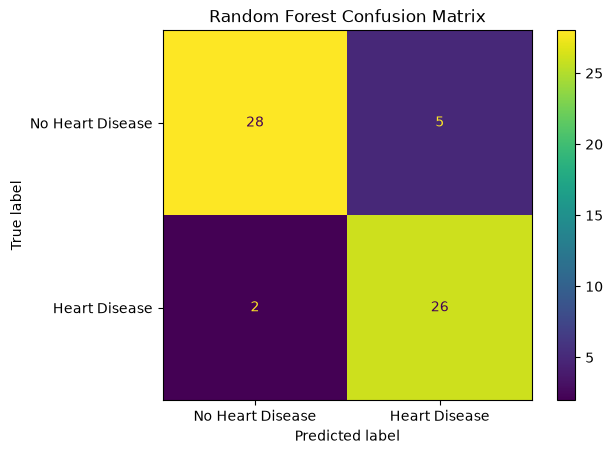

In [142]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["No Heart Disease", "Heart Disease"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The Random Forest model correctly classified <b>28 patients without heart disease</b> and <b>26 patients with heart disease</b>.

It produced <b>5 false positives</b> and <b>2 false negatives</b>. Compared with Logistic Regression, Random Forest reduced the number of false positives from <b>6 to 5</b>, while keeping the same number of false negatives.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
5. ROC Curve and ROC-AUC
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Accuracy and F1-score summarize model performance, but the ROC curve shows how well each model separates the two classes across different classification thresholds.
</p>

</div>

In [157]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for the positive class
logistic_probabilities = baseline_model.predict_proba(
    X_test_scaled
)[:, 1]

rf_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]

# Calculate ROC-AUC scores
logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print(
    "Logistic Regression ROC-AUC:",
    round(logistic_auc, 3)
)

print(
    "Random Forest ROC-AUC:",
    round(rf_auc, 3)
)

Logistic Regression ROC-AUC: 0.953
Random Forest ROC-AUC: 0.954


**Note:**  
I will plot the ROC curves for both models to compare how well they separate the two classes.

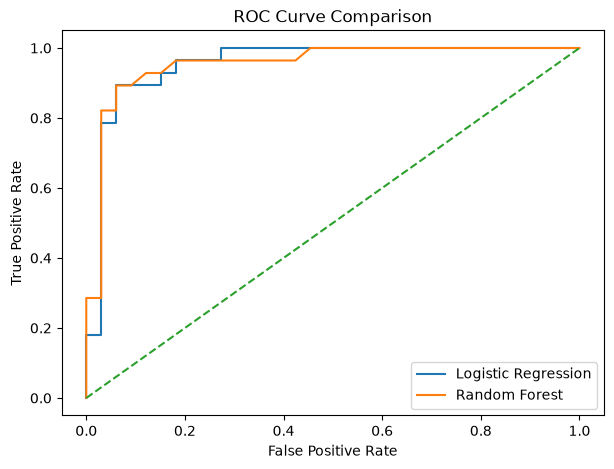

In [159]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(logistic_fpr, logistic_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Both models achieved very high ROC-AUC scores, with <b>0.953</b> for Logistic Regression and <b>0.954</b> for Random Forest.

The two ROC curves are very close, which shows that both models separate the two classes very well across different classification thresholds. Random Forest achieved a slightly higher ROC-AUC, but the difference is very small.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Milestone 4 Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 22px 0;
">
<p style="color:#3F4A52;margin:0;">
Random Forest achieved slightly better performance on the held-out test set, with an F1-score of <b>0.881</b> compared with <b>0.867</b> for Logistic Regression.

However, Logistic Regression achieved the higher average cross-validation F1-score, with <b>0.806</b> compared with <b>0.775</b> for Random Forest.

Both models also achieved very high ROC-AUC scores, with <b>0.953</b> for Logistic Regression and <b>0.954</b> for Random Forest, showing strong class separation.

Overall, Random Forest performed slightly better on the test set, while Logistic Regression showed stronger average performance across the cross-validation folds.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 5 — Feature Engineering & Reusable Pipeline
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Can a cleaner feature setup and a reusable workflow improve the modeling process?
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
The previous milestone compared Logistic Regression and Random Forest. Now I will improve the workflow by creating a small engineered feature and then combining preprocessing and modeling into one reusable Pipeline.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
1. Creating a Simple Engineered Feature
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Age and maximum heart rate already showed useful patterns during EDA. I will combine them into a simple feature that represents maximum heart rate relative to age.
</p>

</div>

In [143]:
# Create a copy before feature engineering
X_engineered = X.copy()

# Maximum heart rate relative to age
X_engineered["thalach_age_ratio"] = (
    X_engineered["thalach"] / X_engineered["age"]
)

X_engineered[["age", "thalach", "thalach_age_ratio"]].head()

,age,thalach,thalach_age_ratio
0,63,150,2.380952
1,67,108,1.611940
2,67,129,1.925373
3,37,187,5.054054
4,41,172,4.195122


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The new <code>thalach_age_ratio</code> feature combines maximum heart rate with age into one value. The first rows show that the ratio changes noticeably across patients, so it may provide additional information for the classification model.
</p>

</div>

In [144]:
# Split the engineered feature set using the same settings
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Engineered training set:", X_eng_train.shape)
print("Engineered testing set:", X_eng_test.shape)

Engineered training set: (242, 14)
Engineered testing set: (61, 14)


<h2 style="color:#2F6F7E;font-weight:bold;">
2. Building a Reusable Pipeline
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Instead of scaling the data manually before training, I will combine scaling and Logistic Regression into one Pipeline. This keeps the workflow cleaner and makes the same preprocessing steps repeatable.
</p>

</div>

In [145]:
from sklearn.pipeline import Pipeline

# Build a reusable pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the full pipeline
logistic_pipeline.fit(
    X_eng_train,
    y_eng_train
)

# Make predictions
pipeline_predictions = logistic_pipeline.predict(
    X_eng_test
)

pipeline_predictions[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [146]:
pipeline_accuracy = accuracy_score(
    y_eng_test,
    pipeline_predictions
)

pipeline_precision = precision_score(
    y_eng_test,
    pipeline_predictions
)

pipeline_recall = recall_score(
    y_eng_test,
    pipeline_predictions
)

pipeline_f1 = f1_score(
    y_eng_test,
    pipeline_predictions
)

print("Pipeline Accuracy:", round(pipeline_accuracy, 3))
print("Pipeline Precision:", round(pipeline_precision, 3))
print("Pipeline Recall:", round(pipeline_recall, 3))
print("Pipeline F1-score:", round(pipeline_f1, 3))

Pipeline Accuracy: 0.869
Pipeline Precision: 0.812
Pipeline Recall: 0.929
Pipeline F1-score: 0.867


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The Pipeline achieved the same performance as the original Logistic Regression baseline, with an accuracy of <b>0.869</b> and an F1-score of <b>0.867</b>.

This means that the new <code>thalach_age_ratio</code> feature did not improve the test performance in this experiment. However, the Pipeline makes the preprocessing and model training cleaner and easier to repeat.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
3. Trying a Second Engineered Feature
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The first engineered feature did not improve the model, so I will try another simple interaction based on two features that showed useful patterns during EDA: age and oldpeak.
</p>

</div>

In [149]:
# Add a second engineered feature
X_engineered_v2 = X.copy()

X_engineered_v2["thalach_age_ratio"] = (
    X_engineered_v2["thalach"] / X_engineered_v2["age"]
)

X_engineered_v2["age_oldpeak_interaction"] = (
    X_engineered_v2["age"] * X_engineered_v2["oldpeak"]
)

X_engineered_v2[
    ["age", "oldpeak", "age_oldpeak_interaction"]
].head()

,age,oldpeak,age_oldpeak_interaction
0,63,2.3,144.9
1,67,1.5,100.5
2,67,2.6,174.2
3,37,3.5,129.5
4,41,1.4,57.4


In [150]:
X_eng2_train, X_eng2_test, y_eng2_train, y_eng2_test = train_test_split(
    X_engineered_v2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [151]:
pipeline_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipeline_v2.fit(
    X_eng2_train,
    y_eng2_train
)

pipeline_v2_predictions = pipeline_v2.predict(
    X_eng2_test
)

In [152]:
pipeline_v2_accuracy = accuracy_score(
    y_eng2_test,
    pipeline_v2_predictions
)

pipeline_v2_precision = precision_score(
    y_eng2_test,
    pipeline_v2_predictions
)

pipeline_v2_recall = recall_score(
    y_eng2_test,
    pipeline_v2_predictions
)

pipeline_v2_f1 = f1_score(
    y_eng2_test,
    pipeline_v2_predictions
)

print("Pipeline V2 Accuracy:", round(pipeline_v2_accuracy, 3))
print("Pipeline V2 Precision:", round(pipeline_v2_precision, 3))
print("Pipeline V2 Recall:", round(pipeline_v2_recall, 3))
print("Pipeline V2 F1-score:", round(pipeline_v2_f1, 3))

Pipeline V2 Accuracy: 0.869
Pipeline V2 Precision: 0.812
Pipeline V2 Recall: 0.929
Pipeline V2 F1-score: 0.867


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The second engineered feature also produced the same model performance, with an F1-score of <b>0.867</b>.

This suggests that the original features already contain most of the useful information needed by Logistic Regression, and these additional interactions did not provide a measurable improvement on the test set.
</p>

</div>

In [153]:
feature_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Pipeline V1",
        "Pipeline V2"
    ],
    "Accuracy": [
        baseline_accuracy,
        pipeline_accuracy,
        pipeline_v2_accuracy
    ],
    "Precision": [
        baseline_precision,
        pipeline_precision,
        pipeline_v2_precision
    ],
    "Recall": [
        baseline_recall,
        pipeline_recall,
        pipeline_v2_recall
    ],
    "F1-score": [
        baseline_f1,
        pipeline_f1,
        pipeline_v2_f1
    ]
})

feature_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline Logistic Regression,0.869,0.812,0.929,0.867
1,Pipeline V1,0.869,0.812,0.929,0.867
2,Pipeline V2,0.869,0.812,0.929,0.867


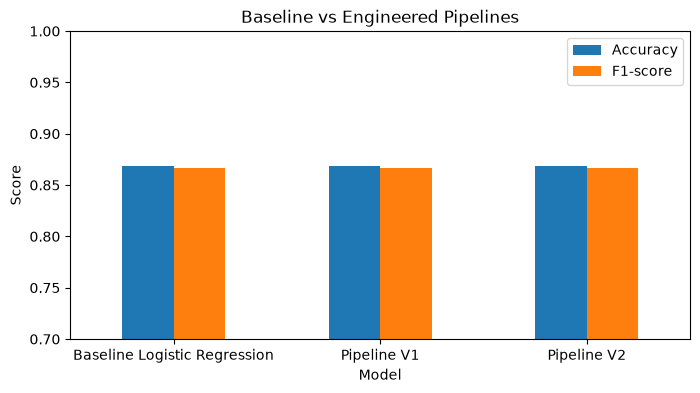

In [154]:
feature_comparison.set_index("Model")[["Accuracy", "F1-score"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.ylabel("Score")
plt.title("Baseline vs Engineered Pipelines")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Final Comparison
</p>

<p style="color:#3F4A52;margin-bottom:0;">
All three versions achieved the same test performance. The engineered features did not improve the Logistic Regression results, but the Pipeline created a cleaner and more repeatable workflow for preprocessing and model training.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Milestone 5 Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 22px 0;
">

<p style="color:#3F4A52;margin:0;">
Two simple engineered features were tested, but neither improved the Logistic Regression test performance. The main improvement in this milestone was the use of a Scikit-learn Pipeline, which combined scaling and modeling into one consistent workflow.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 7 — Final Review & Project Summary
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Bringing the full analysis together into one clear and reproducible final project
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
1. Final Model Results
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The project tested Logistic Regression, Random Forest, and two engineered Pipeline versions. The final results can now be summarized in one place.
</p>

</div>

In [155]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Pipeline V1",
        "Pipeline V2"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        pipeline_accuracy,
        pipeline_v2_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_precision,
        pipeline_precision,
        pipeline_v2_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall,
        pipeline_recall,
        pipeline_v2_recall
    ],
    "F1-score": [
        baseline_f1,
        rf_f1,
        pipeline_f1,
        pipeline_v2_f1
    ]
})

final_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.869,0.812,0.929,0.867
1,Random Forest,0.885,0.839,0.929,0.881
2,Pipeline V1,0.869,0.812,0.929,0.867
3,Pipeline V2,0.869,0.812,0.929,0.867


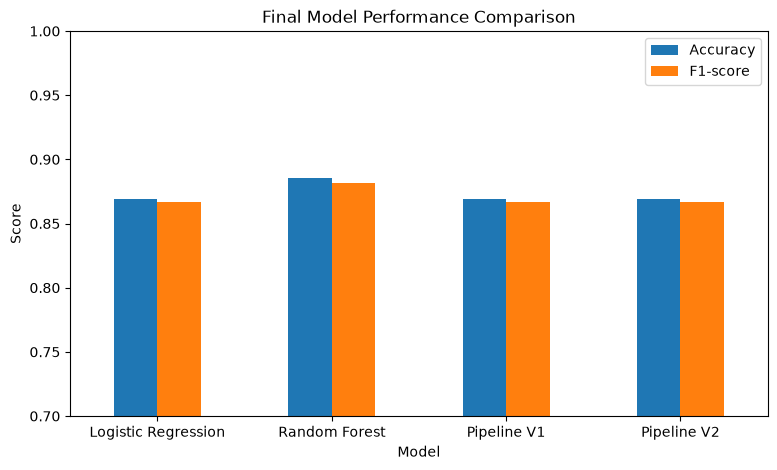

In [156]:
final_results.set_index("Model")[["Accuracy", "F1-score"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.title("Final Model Performance Comparison")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Final Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Random Forest achieved the highest test performance, with an accuracy of <b>0.885</b> and an F1-score of <b>0.881</b>. Logistic Regression and both engineered Pipeline versions achieved an F1-score of <b>0.867</b>. However, Logistic Regression showed the higher average cross-validation F1-score, which suggests more consistent performance across the folds.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
2. Key Findings
</h2>

<div style="
    background:#F6F9FA;
    border:1px solid #DCE5E8;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 18px 0;
">

<ul style="color:#3F4A52;line-height:1.7;margin-bottom:0;">

<li>The dataset was clean, with no missing values or duplicate records.</li>

<li>Heart disease cases represented about <b>45.9%</b> of the dataset, so the classes were fairly balanced.</li>

<li>EDA showed useful patterns in features such as <code>thal</code>, <code>ca</code>, <code>exang</code>, <code>oldpeak</code>, and <code>thalach</code>.</li>

<li>Random Forest achieved the highest test F1-score at <b>0.881</b>.</li>

<li>Logistic Regression achieved a slightly lower test F1-score of <b>0.867</b>, but performed better on average during cross-validation with a mean F1-score of <b>0.806</b>.</li>

<li>The engineered features did not improve Logistic Regression performance in this experiment.</li>

<li>The Pipeline made the preprocessing and model-training workflow cleaner and easier to repeat.</li>

</ul>

</div>

<h2 style="color:#16324F;font-weight:bold;">
3. Project Limitations
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 18px 0;
">

<ul style="color:#3F4A52;line-height:1.7;margin-bottom:0;">

<li>The dataset contains only <b>303 patient records</b>, so results may change with a larger dataset.</li>

<li>The project uses only the features available in the selected dataset.</li>

<li>The engineered features tested in this project did not improve the final model performance.</li>

<li>Model performance may vary across different train/test splits, which is why cross-validation was also used.</li>

<li>This project is intended for machine-learning analysis and not for clinical diagnosis or treatment decisions.</li>

</ul>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Final Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#16324F,#2F6F7E);
    border-radius:14px;
    padding:20px 22px;
    margin:12px 0 22px 0;
">

<p style="color:white;line-height:1.8;margin:0;">
This project followed a complete machine-learning workflow, starting with data understanding and exploratory analysis, then moving to supervised classification, model comparison, cross-validation, feature engineering, and a reusable Pipeline.

Random Forest achieved the strongest performance on the held-out test set, while Logistic Regression showed stronger average performance across the cross-validation folds.

Overall, the analysis showed that model evaluation should not depend on a single metric or a single data split, and that feature engineering does not always guarantee better performance.
</p>

</div>